# MecâniQA - Encontro 4 (02/09/2026)

Objetivo: baselines Naive e Média Móvel **sem olhar o futuro** (sem Data Leakage).

## 1. Importar bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Preparar a série

Mesma base dos encontros anteriores. Interpolamos os 6 dias vazios de abril/2024 para a janela de 7 dias não quebrar.

In [ ]:
df = pd.read_csv("data/mecaniqa_dataset.csv")
df["Data"] = pd.to_datetime(df["Data"])
df = df.set_index("Data").sort_index()

serie = df["Trocas_Oleo"].interpolate(method="time")
serie.name = "Trocas_Oleo"
serie.head()

,Trocas_Oleo
Data,
2024-01-01,11.0
2024-01-02,9.0
2024-01-03,12.0
2024-01-04,15.0
2024-01-05,25.0


## 3. Funções de baseline

`shift(1)` garante que o dia `t` só vê até `t-1`. Sem isso, `.rolling(7).mean()` incluiria o valor de hoje na "previsão" de hoje.

In [ ]:
def previsao_naive(serie):
    """Previsão de hoje = valor exato de ontem."""
    return serie.shift(1)


def previsao_media_movel(serie, janela=7):
    """Média dos últimos `janela` dias já observados (sem incluir hoje)."""
    return serie.shift(1).rolling(window=janela).mean()


y_hat_naive = previsao_naive(serie)
y_hat_mm7 = previsao_media_movel(serie, janela=7)

comparacao = pd.DataFrame({
    "real": serie,
    "naive": y_hat_naive,
    "media_movel_7": y_hat_mm7,
})
comparacao.head(10)

,real,naive,media_movel_7
Data,,,
2024-01-01,11.0,NaN,NaN
2024-01-02,9.0,11.0,NaN
2024-01-03,12.0,9.0,NaN
2024-01-04,15.0,12.0,NaN
2024-01-05,25.0,15.0,NaN
2024-01-06,25.0,25.0,NaN
2024-01-07,31.0,25.0,NaN
2024-01-08,13.0,31.0,18.285714
2024-01-09,10.0,13.0,18.571429


## 4. QA — nenhuma previsão em t usa t+1 (nem t)

No Naive, a previsão do dia `t` tem de ser igual ao real de `t-1`.
Na MM7, a previsão do dia `t` é a média de `t-1` até `t-7`.

In [ ]:
naive_ok = y_hat_naive.dropna().equals(serie.shift(1).dropna())
mm_ok = y_hat_mm7.dropna().equals(serie.shift(1).rolling(7).mean().dropna())

vazou_naive = (y_hat_naive == serie).loc[y_hat_naive.dropna().index].all()
vazou_mm = (y_hat_mm7 == serie.rolling(7).mean()).loc[y_hat_mm7.dropna().index].all()

print("Naive == shift(1):", naive_ok)
print("MM7 == shift(1).rolling(7).mean():", mm_ok)
print("Naive copiou o próprio dia t? (teria leakage):", bool(vazou_naive))
print("MM7 usou a janela centrada em t? (teria leakage):", bool(vazou_mm))

amostra = comparacao.iloc[10:17].copy()
amostra["naive_deveria"] = comparacao["real"].shift(1).iloc[10:17]
amostra

Naive == shift(1): True
MM7 == shift(1).rolling(7).mean(): True
Naive copiou o próprio dia t? (teria leakage): False
MM7 usou a janela centrada em t? (teria leakage): False


,real,naive,media_movel_7,naive_deveria
Data,,,,
2024-01-11,10.0,13.0,18.857143,13.0
2024-01-12,25.0,10.0,18.142857,10.0
2024-01-13,28.0,25.0,18.142857,25.0
2024-01-14,22.0,28.0,18.571429,28.0
2024-01-15,7.0,22.0,17.285714,22.0
2024-01-16,11.0,7.0,16.428571,7.0
2024-01-17,10.0,11.0,16.571429,11.0


## 5. Gráfico — real x Naive x MM7

Janela recente (90 dias) para o atraso de 1 dia aparecer no gráfico. O Naive acompanha o real com um degrau; a média de 7 dias suaviza o fim de semana.

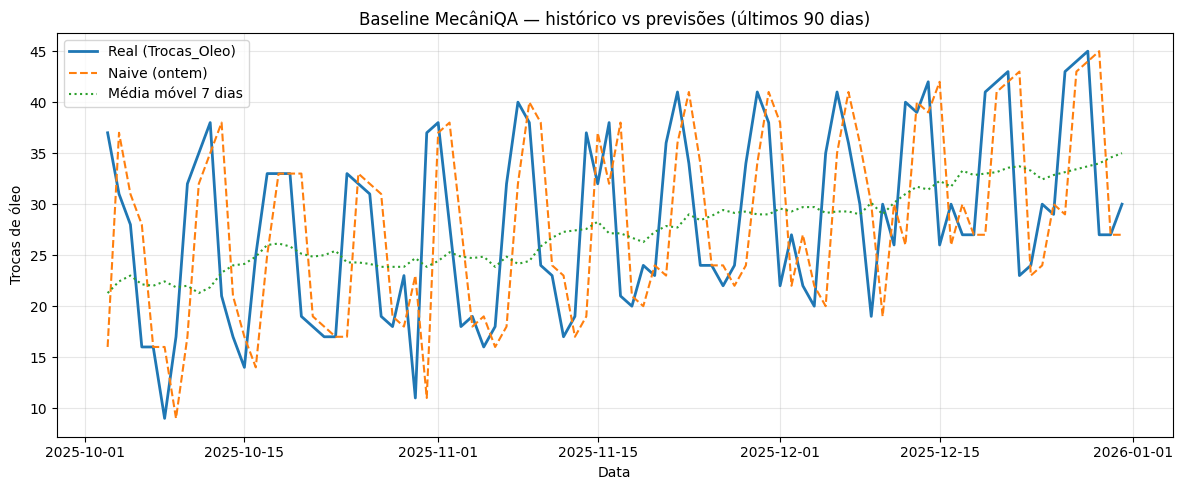

In [ ]:
janela_plot = comparacao.iloc[-90:]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(janela_plot.index, janela_plot["real"], label="Real (Trocas_Oleo)", linewidth=2)
ax.plot(janela_plot.index, janela_plot["naive"], label="Naive (ontem)", linestyle="--")
ax.plot(janela_plot.index, janela_plot["media_movel_7"], label="Média móvel 7 dias", linestyle=":")
ax.set_title("Baseline MecâniQA — histórico vs previsões (últimos 90 dias)")
ax.set_xlabel("Data")
ax.set_ylabel("Trocas de óleo")
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()